# Correct变量总和大于等于96

In [2]:
import os
import pandas as pd

# 输入文件夹路径
input_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data'
# 输出文件夹路径
output_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data1'

# 创建输出文件夹（如果不存在）
os.makedirs(output_folder, exist_ok=True)

# 遍历输入文件夹中的所有xlsx文件
for file_name in os.listdir(input_folder):
    if file_name.endswith('.xlsx'):
        # 读取Excel文件
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        
        # 统计Correct变量的总和
        correct_sum = df['Correct'].sum()
        
        # 如果Correct变量总和大于等于96，将数据保存在新的文件夹下
        if correct_sum >= 96:
            output_file_path = os.path.join(output_folder, file_name)
            df.to_excel(output_file_path, index=False)

print("数据处理完成，符合条件的数据已保存到新的文件夹中。")

数据处理完成，符合条件的数据已保存到新的文件夹中。


# 删除RT变量小于0.2的行数据

In [3]:
import os
import pandas as pd

# 输入文件夹路径
input_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data1'
# 输出文件夹路径
output_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data2'

# 创建输出文件夹（如果不存在）
os.makedirs(output_folder, exist_ok=True)

# 遍历输入文件夹中的所有xlsx文件
for file_name in os.listdir(input_folder):
    if file_name.endswith('.xlsx'):
        # 读取Excel文件
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        
        # 删除RT变量小于0.2的行数据
        df_filtered = df[df['RT'] >= 0.3]
        
        # 将处理后的数据保存在新的文件夹下
        output_file_path = os.path.join(output_folder, file_name)
        df_filtered.to_excel(output_file_path, index=False)

print("数据处理完成，并保存到新的文件夹中。")

数据处理完成，并保存到新的文件夹中。


# 筛选正确率大于2个标准差阈值

In [4]:
import os
import pandas as pd

# 输入文件夹路径
input_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data2'
# 输出文件夹路径
output_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data3'

# 创建输出文件夹（如果不存在）
os.makedirs(output_folder, exist_ok=True)

correct_sums = []

# 第一次遍历，计算每个被试的Correct总和
for file_name in os.listdir(input_folder):
    if file_name.endswith('.xlsx'):
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        correct_sum = df['Correct'].sum()
        correct_sums.append((file_name, correct_sum))

# 将Correct总和提取出来用于计算均值和标准差
correct_values = [x[1] for x in correct_sums]

# 计算均值和标准差
mean_correct = sum(correct_values) / len(correct_values)
std_correct = pd.Series(correct_values).std()

# 计算阈值
threshold = mean_correct - 2 * std_correct

# 第二次遍历，删除不符合条件的被试数据
for file_name, correct_sum in correct_sums:
    if correct_sum >= threshold:
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        output_file_path = os.path.join(output_folder, file_name)
        df.to_excel(output_file_path, index=False)

print(f"数据处理完成，符合条件的数据已保存到新的文件夹中。均值: {mean_correct}, 标准差: {std_correct}, 阈值: {threshold}")


数据处理完成，符合条件的数据已保存到新的文件夹中。均值: 129.25, 标准差: 14.352700094407323, 阈值: 100.54459981118535


# 筛选RT 2个标准差阈值

In [5]:
import os
import pandas as pd

# 输入文件夹路径
input_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data3'
# 输出文件夹路径
output_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data4'

# 创建输出文件夹（如果不存在）
os.makedirs(output_folder, exist_ok=True)

rt_means = []

# 第一次遍历，计算每个被试的RT平均值
for file_name in os.listdir(input_folder):
    if file_name.endswith('.xlsx'):
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        rt_mean = df['RT'].mean()
        rt_means.append((file_name, rt_mean))

# 将RT均值提取出来用于计算均值和标准差
rt_values = [x[1] for x in rt_means]

# 计算均值和标准差
mean_rt = sum(rt_values) / len(rt_values)
std_rt = pd.Series(rt_values).std()

# 计算阈值
lower_threshold = mean_rt - 2 * std_rt
upper_threshold = mean_rt + 2 * std_rt

# 第二次遍历，删除不符合条件的被试数据
for file_name, rt_mean in rt_means:
    if lower_threshold <= rt_mean <= upper_threshold:
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        output_file_path = os.path.join(output_folder, file_name)
        df.to_excel(output_file_path, index=False)

print(f"数据处理完成，符合条件的数据已保存到新的文件夹中。均值: {mean_rt}, 标准差: {std_rt}, 下限阈值: {lower_threshold}, 上限阈值: {upper_threshold}")


数据处理完成，符合条件的数据已保存到新的文件夹中。均值: 2.6390777905591274, 标准差: 0.5042892187691962, 下限阈值: 1.630499353020735, 上限阈值: 3.64765622809752


In [6]:
import os
import pandas as pd

# 输入文件夹路径
input_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data4'
# 输出文件夹路径
output_folder = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data5'

# 创建输出文件夹（如果不存在）
os.makedirs(output_folder, exist_ok=True)

# 遍历输入文件夹中的所有xlsx文件
for file_name in os.listdir(input_folder):
    if file_name.endswith('.xlsx'):
        # 读取Excel文件
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_excel(file_path)
        
        # 初始化Frequency变量
        df['Frequency'] = 0
        
        # 根据条件设置Frequency的值
        df.loc[(df['Finger'] == 0) & (df['Shape'].isin([1, 2, 3, 4])), 'Frequency'] = 1
        df.loc[(df['Finger'] == 0) & (df['Shape'].isin([5, 6, 7, 8])), 'Frequency'] = 2
        df.loc[(df['Finger'] == 1) & (df['Shape'].isin([1, 2, 3, 4])), 'Frequency'] = 2
        df.loc[(df['Finger'] == 1) & (df['Shape'].isin([5, 6, 7, 8])), 'Frequency'] = 1
        
        # 将处理后的数据保存在新的文件夹下
        output_file_path = os.path.join(output_folder, file_name)
        df.to_excel(output_file_path, index=False)

print("数据处理完成，并保存到新的文件夹中。")


数据处理完成，并保存到新的文件夹中。


In [7]:
import pandas as pd
import numpy as np
import os

# Assuming the 31 subjects' data are in separate Excel files in a directory called 'subjects_data'
data_path = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data5'  # Directory containing the subject files
subject_files = sorted([f for f in os.listdir(data_path) if f.endswith('.xlsx')])

# Initialize an empty DataFrame to store the results
result_df = pd.DataFrame(columns=['subject', 'RT', 'correct', 'finger', 'frequency'])

# Loop through each subject file, process the data, and append to result_df
for i, file in enumerate(subject_files, start=1):
    # Read the Excel file for the current subject
    file_path = os.path.join(data_path, file)
    df = pd.read_excel(file_path)
    
    # Group by 'Finger' and 'Frequency' and calculate the mean RT and sum of Correct
    grouped = df.groupby(['Finger', 'Frequency']).agg(
        RT_mean=('RT', 'mean'),
        Correct_sum=('Correct', 'sum')
    ).reset_index()
    
    # Add the subject identifier
    grouped['subject'] = i
    
    # Append the grouped results to the result DataFrame
    result_df = pd.concat([result_df, grouped.rename(columns={'RT_mean': 'RT', 'Correct_sum': 'correct', 'Finger': 'finger', 'Frequency': 'frequency'})], ignore_index=True)



print(result_df)

/var/folders/wd/1vvvm8_1081fd4hv72tr3rrm0000gn/T/ipykernel_41148/1260193354.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, grouped.rename(columns={'RT_mean': 'RT', 'Correct_sum': 'correct', 'Finger': 'finger', 'Frequency': 'frequency'})], ignore_index=True)


    subject        RT correct finger frequency
0         1  3.055491      33      0         1
1         1  3.201338      33      0         2
2         1  3.217882      36      1         1
3         1  3.369599      35      1         2
4         2  2.555264      34      0         1
..      ...       ...     ...    ...       ...
111      28  3.309630      31      1         2
112      29  2.006789      27      0         1
113      29  1.919680      25      0         2
114      29  1.823607      31      1         1
115      29  1.953120      29      1         2

[116 rows x 5 columns]


In [8]:
result_df['correct'] = pd.to_numeric(result_df['correct'], errors='coerce')

# 检查并处理可能的NaN值
result_df = result_df.dropna(subset=['correct'])

In [9]:
import pandas as pd
import pingouin as pg
pg.rm_anova(dv='RT', within=['finger', 'frequency'], subject='subject', data=result_df, detailed=True,correction=True)

/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,finger,2.894692e-07,1,28,2.894692e-07,0.000010,0.997536,0.997536,1.267582e-08,1.0
1,frequency,6.490961e-04,1,28,6.490961e-04,0.055111,0.816105,0.816105,2.842304e-05,1.0
2,finger * frequency,7.246104e-02,1,28,7.246104e-02,3.988897,0.055603,0.055603,3.163025e-03,1.0


In [10]:
aov = pg.rm_anova(dv='RT', within=['finger','frequency'], subject='subject',
                  data=result_df, detailed=True, correction=True)
print(aov.round(3))

               Source     SS  ddof1  ddof2     MS      F  p-unc  p-GG-corr  \
0              finger  0.000      1     28  0.000  0.000  0.998      0.998   
1           frequency  0.001      1     28  0.001  0.055  0.816      0.816   
2  finger * frequency  0.072      1     28  0.072  3.989  0.056      0.056   

     ng2  eps  
0  0.000  1.0  
1  0.000  1.0  
2  0.003  1.0  


/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [14]:
pg.pairwise_tests(dv='correct', within='finger', subject='subject', data=result_df, padjust='fdr_bh')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,finger,0,1,True,True,-3.406307,28.0,two-sided,0.00201,18.119,-0.611084


In [15]:
aov = pg.rm_anova(dv='correct', within=['finger','frequency'], subject='subject',
                  data=result_df, detailed=True, correction=True)
print(aov.round(3))

               Source       SS  ddof1  ddof2       MS       F  p-unc  \
0              finger  134.698      1     28  134.698  11.603  0.002   
1           frequency    7.250      1     28    7.250   1.112  0.301   
2  finger * frequency    1.043      1     28    1.043   0.139  0.712   

   p-GG-corr    ng2  eps  
0      0.002  0.072  1.0  
1      0.301  0.004  1.0  
2      0.712  0.001  1.0  


/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [12]:
import os
import pandas as pd
import numpy as np

# 数据所在的文件夹路径 (处理后的最终数据)
data_path = r'/Users/zhangqianqian/Documents/PKU/实验/实验一数据/data(1)/data5'
subject_files = sorted([f for f in os.listdir(data_path) if f.endswith('.xlsx')])

ages = []
gender_list = []

# 遍历所有被试的 Excel 文件
for file in subject_files:
    file_path = os.path.join(data_path, file)
    try:
        df = pd.read_excel(file_path)
        
        # 尝试提取年龄信息，假设每张表里的年龄都是一致的，取第一个非空值
        if 'Age' in df.columns:
            age_val = df['Age'].dropna().iloc[0]
            ages.append(age_val)
        elif 'age' in df.columns:
            age_val = df['age'].dropna().iloc[0]
            ages.append(age_val)
            
        # 如果需要统计性别，可以取消以下注释并根据您的列名修改：
        # if 'Sex' in df.columns:
        #     gender_list.append(df['Sex'].dropna().iloc[0])
            
    except Exception as e:
        print(f"读取文件 {file} 时出错: {e}")

# 1. 计算被试总数
num_subjects = len(subject_files)
print(f"============ 基本描述统计 ============")
print(f"最终有效被试总数 (N): {num_subjects} 人")

# 2. 计算年龄的均值和标准误(SE)
if ages:
    ages_array = np.array(ages, dtype=float)
    # 去除可能存在的 NaN 异常值
    ages_array = ages_array[~np.isnan(ages_array)] 
    
    val_num = len(ages_array)
    mean_age = np.mean(ages_array)
    # 计算标准误 SE = 标准差 / 根号N (自由度 ddof=1)
    se_age = np.std(ages_array, ddof=1) / np.sqrt(val_num) 
    
    print(f"被试年龄均值 (Mean): {mean_age:.2f} 岁")
    print(f"被试年龄标准误 (SE): {se_age:.2f}")
    # 附带标准差通常更常见于被试描述
    std_age = np.std(ages_array, ddof=1)
    print(f"被试年龄标准差 (SD): {std_age:.2f}")
else:
    print("\n提示：在 Excel 数据表中未找到名为 'Age' 或 'age' 的列，无法进行年龄统计。")

============ 基本描述统计 ============
最终有效被试总数 (N): 29 人
被试年龄均值 (Mean): 21.93 岁
被试年龄标准误 (SE): 0.41
被试年龄标准差 (SD): 2.20


/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
/var/folders/wd/1vvvm8_1081fd4hv72tr3rrm0000gn/T/ipykernel_41148/2142603223.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


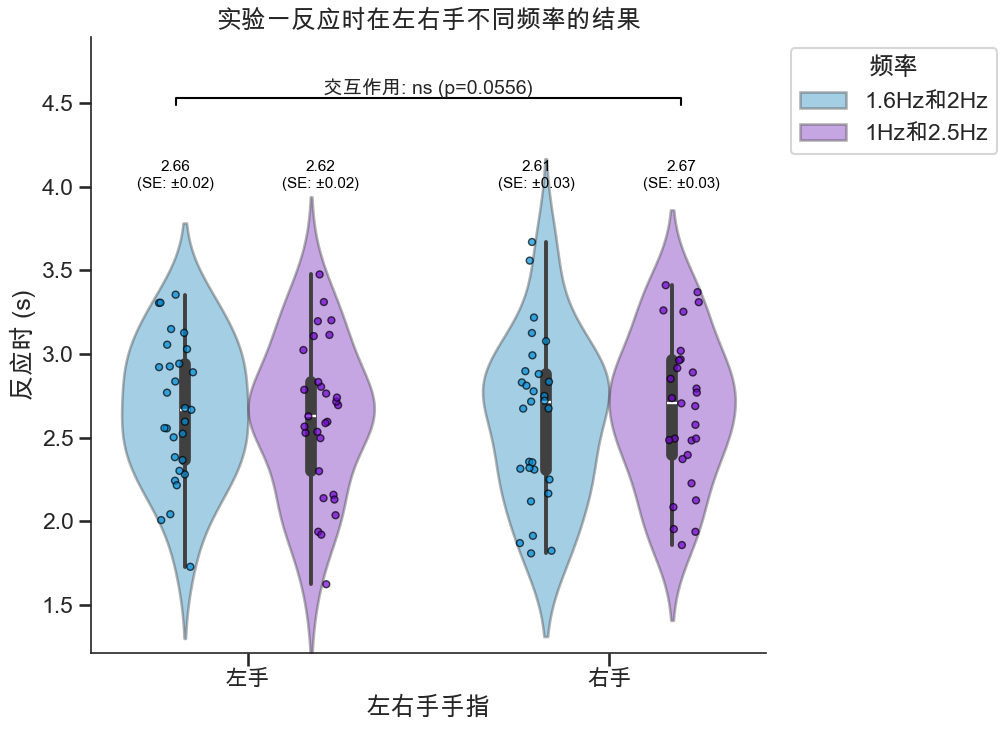

In [19]:
# Python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# ---- 1) 解决 macOS 下中文显示 ---
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # macOS 适用
plt.rcParams['axes.unicode_minus'] = False
# -----------------------------------

# a) 提取整理数据 (每被试每个条件的均值)
df = result_df.dropna(subset=['subject','finger','frequency','RT']).copy()
df_subj = (df.groupby(['subject','finger','frequency'], as_index=False)['RT'].mean())

# b) 计算组内 SE（Cousineau–Morey）以及总均值
grand = df_subj['RT'].mean()
df_subj['RT_norm'] = df_subj['RT'] - df_subj.groupby('subject')['RT'].transform('mean') + grand
k = int(df_subj.groupby('subject').size().mode().iloc[0])  # 条件数
morey = np.sqrt(k/(k-1)) if k > 1 else 1.0

summary = (df_subj.groupby(['finger','frequency'])
           .agg(mean=('RT','mean'),
                se_ws=('RT_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
           .reset_index())
summary['se_ws'] *= morey

finger_order = sorted(summary['finger'].unique(), key=lambda x: (str(type(x)), x))
hue_order = sorted(df['frequency'].dropna().unique())

# ---- 2) 开始绘图：风琴图(小提琴图) + 散点(数据点) ----
sns.set(style='ticks', context='talk')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 8))
custom_colors = ["#028DD8", "#7205D1"]

# 画风琴图（透明度设为 alpha=0.5 以便看清散点）
sns.violinplot(
    data=df_subj, x='finger', y='RT', hue='frequency',
    order=finger_order, hue_order=hue_order,
    inner="box", palette=custom_colors, ax=ax, width=0.7, density_norm="width", alpha=0.4
)

# 叠加原始数据点（stripplot），通过 dodge=True 让点跟随 hue 分开
sns.stripplot(
    data=df_subj, x='finger', y='RT', hue='frequency',
    order=finger_order, hue_order=hue_order,
    dodge=True, edgecolor='black', linewidth=1, alpha=0.7, size=5, palette=custom_colors, ax=ax
)

# 动态计算Y轴上下限，给顶部的横线和文字留足空间
y_max = df_subj['RT'].max()
y_min = df_subj['RT'].min()
yr = y_max - y_min  # Y轴的数据跨度
ax.set_ylim(y_min - 0.2 * yr, y_max + 0.6 * yr)  # 上端大大留白 (增加了 +0.6 * yr)

# 巧妙地在风琴图顶部写上“均值(SE)”
for i, finger in enumerate(finger_order):
    for j, freq in enumerate(hue_order):
        # seaborn里面 hue 如果有两个条件，X轴向左右分别偏移大约 -0.2 和 0.2
        offset = -0.2 if j == 0 else 0.2
        x_pos = i + offset
        
        row = summary.loc[(summary['finger']==finger) & (summary['frequency']==freq)].iloc[0]
        m_val = row['mean']
        se_val = row['se_ws']
        
        # 把代表均值的文字直接写在图上，位置提升避免与图和连线重叠
        ax.text(x_pos, y_max + 0.15 * yr, f'{m_val:.2f}\n(SE: ±{se_val:.2f})',
                ha='center', va='bottom', fontsize=11, color='black')

# ---- 3) 保留顶部的“总体交互作用”连线 ----
aov = pg.rm_anova(dv='RT', within=['finger','frequency'], subject='subject', data=df_subj, detailed=True)
p_inter = aov[aov['Source'] == 'finger * frequency']['p-unc'].iloc[0]
stars_inter = 'ns' if p_inter >= 0.05 else ('*' if p_inter >= 0.01 else ('**' if p_inter >= 0.001 else '***'))

x_min, x_max = -0.2, len(finger_order) - 1 + 0.2
y_inter = y_max + 0.40 * yr  # 交互作用连线位置进一步上移，防止挡到上面的数字
ax.plot([x_min, x_min, x_max, x_max], [y_inter, y_inter + 0.02 * yr, y_inter + 0.02 * yr, y_inter], color='black', linewidth=1.5)
ax.text((x_min + x_max) / 2, y_inter + 0.02 * yr, f'交互作用: {stars_inter} (p={p_inter:.3g})', 
        ha='center', va='bottom', fontsize=14, fontweight='bold')

# ---- 4) 整理图例与外框 ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

ax.set_ylabel('反应时 (s)')
ax.set_xlabel('左右手手指')
ax.set_title('实验一反应时在左右手不同频率的结果')

# 解析图例 (注意去除 stripplot 产生的重复图例)
handles, labels = ax.get_legend_handles_labels()
handles = handles[:len(hue_order)]
labels = labels[:len(hue_order)]

freq_map = {'1': '1.6Hz和2Hz', '2': '1Hz和2.5Hz'}  
new_labels = [freq_map.get(str(l).split('.')[0], str(l)) for l in labels]
ax.legend(handles=handles, labels=new_labels, title='频率', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
plt.subplots_adjust(right=0.80)

label_map = {'0':'左手','1':'右手','0.0':'左手','1.0':'右手'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

plt.show()

/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
/var/folders/wd/1vvvm8_1081fd4hv72tr3rrm0000gn/T/ipykernel_31019/3494275965.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


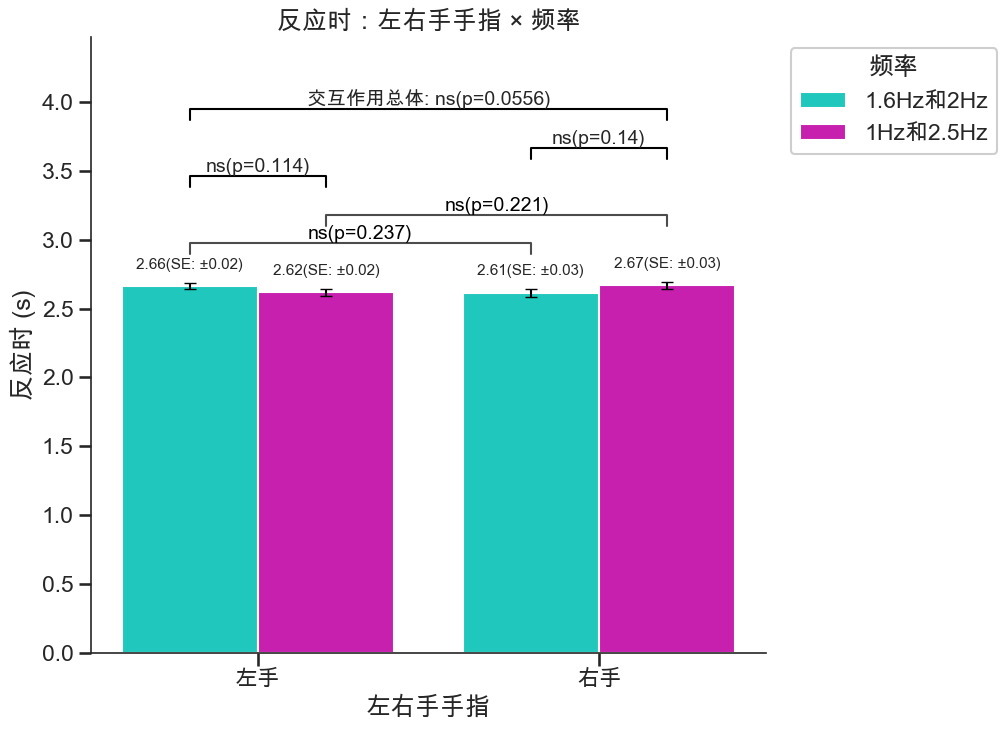

In [12]:
# Python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# ---- 1) 解决 macOS 下中文显示问题 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # macOS 适用
plt.rcParams['axes.unicode_minus'] = False
# -----------------------------------

# 用与 ANOVA 相同的数据子集
df = result_df.dropna(subset=['subject','finger','frequency','RT']).copy()

# 每被试×条件均值（用于组内 SE）
df_subj = (df.groupby(['subject','finger','frequency'], as_index=False)['RT']
             .mean())

# 组内 SE（Cousineau–Morey）
grand = df_subj['RT'].mean()
df_subj['RT_norm'] = df_subj['RT'] - df_subj.groupby('subject')['RT'].transform('mean') + grand
k = int(df_subj.groupby('subject').size().mode().iloc[0])  # 条件数
morey = np.sqrt(k/(k-1)) if k > 1 else 1.0

summary = (df_subj.groupby(['finger','frequency'])
           .agg(mean=('RT','mean'),
                se_ws=('RT_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
           .reset_index())
summary['se_ws'] *= morey

# 排序，确保误差条与柱子一一对应
finger_order = sorted(summary['finger'].unique(), key=lambda x: (str(type(x)), x))
hue_order = sorted(df['frequency'].dropna().unique())
summary['finger'] = pd.Categorical(summary['finger'], categories=finger_order, ordered=True)
summary['frequency'] = pd.Categorical(summary['frequency'], categories=hue_order, ordered=True)
summary_plot = summary.sort_values(['finger','frequency']).reset_index(drop=True)

# 绘图
# 去除背景的条纹，使用 'ticks' 或者 'white'
sns.set(style='ticks', context='talk')

# 注意：sns.set() 会重置字体设置，设定完主题后需要再次应用中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 8))

# ------------ 【在这里修改颜色】 ------------
# 支持十六进制（如 '#8FB0D3'）或者自带颜色名（如 'lightblue', 'lightgreen', 'pink'）
# 第一项为 frequency 第一个条件的颜色，第二项为 frequency 第二个条件的颜色
custom_colors = ["#04e3d4", "#e304c2"]
# ----------------------------------------

sns.barplot(
    data=summary_plot, x='finger', y='mean', hue='frequency',
    order=finger_order, hue_order=hue_order,
    errorbar=None, palette=custom_colors, ax=ax
)
# 上限留白，增加以便留出足够的空间画 p 值连线和交互作用连线
top = (summary_plot['mean'] + summary_plot['se_ws']).max()
ax.set_ylim(0, top * 1.5)

# 误差条 + 数值标签
ymin, ymax = ax.get_ylim(); yr = ymax - ymin

# 【核心修复】：Seaborn的 patch 顺序是按 hue 再按 x，所以数值也要这样排序，才能一一对应
patch_order_df = summary_plot.sort_values(['frequency', 'finger']).reset_index(drop=True)

for patch, (_, row) in zip(ax.patches, patch_order_df.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    ax.errorbar(x, y, yerr=row['se_ws'], fmt='none', ecolor='black',
                elinewidth=1.5, capsize=4)
    # 保留两位小数
    ax.text(x, y + row['se_ws'] + 0.02*yr, f'{row["mean"]:.2f}(SE: ±{row["se_ws"]:.2f})',
            ha='center', va='bottom', fontsize=11, clip_on=False)
    
# ---- 2) 添加简单效应(配对t检验) ----
# 第一组：同一频次下，手指0 vs 1
y_line_freq = top + 0.05 * yr
if len(finger_order) >= 2:
    val_f1, val_f2 = finger_order[0], finger_order[1]
    for j, freq in enumerate(hue_order):
        d1 = df_subj[(df_subj['finger'] == val_f1) & (df_subj['frequency'] == freq)].set_index('subject')['RT']
        d2 = df_subj[(df_subj['finger'] == val_f2) & (df_subj['frequency'] == freq)].set_index('subject')['RT']
        common = d1.index.intersection(d2.index)
        if len(common) >= 2:
            res = pg.ttest(d1.loc[common], d2.loc[common], paired=True)
            p_val = float(res['p-val'].iloc[0])
            stars = 'ns' if p_val >= 0.05 else ('*' if p_val >= 0.01 else ('**' if p_val >= 0.001 else '***'))
            
            x0 = ax.patches[j * len(finger_order)].get_x() + ax.patches[j * len(finger_order)].get_width() / 2
            x1 = ax.patches[j * len(finger_order) + 1].get_x() + ax.patches[j * len(finger_order) + 1].get_width() / 2
            
            y_line = y_line_freq + j * 0.05 * yr
            c = 'blue' if j == 0 else 'purple'
            ax.plot([x0, x0, x1, x1], [y_line, y_line + 0.02 * yr, y_line + 0.02 * yr, y_line], color='black', linewidth=1.5, alpha=0.7)
            ax.text((x0 + x1) / 2, y_line + 0.02 * yr, f'{stars}(p={p_val:.3g})', ha='center', va='bottom', fontsize=14, color='black')

# 第二组：同一手指下，频次1 vs 2
y_line_finger = y_line_freq + 0.12 * yr
for i, fing in enumerate(finger_order):
    if len(hue_order) >= 2:
        val1, val2 = hue_order[0], hue_order[1]
        
        # 取两个 frequency 分组
        d1 = df_subj[(df_subj['finger'] == fing) & (df_subj['frequency'] == val1)].set_index('subject')['RT']
        d2 = df_subj[(df_subj['finger'] == fing) & (df_subj['frequency'] == val2)].set_index('subject')['RT']
        
        common_subjects = d1.index.intersection(d2.index)
        if len(common_subjects) >= 2:
            res = pg.ttest(d1.loc[common_subjects], d2.loc[common_subjects], paired=True)
            p_val = float(res['p-val'].iloc[0])
            stars = 'ns' if p_val >= 0.05 else ('*' if p_val >= 0.01 else ('**' if p_val >= 0.001 else '***'))
            
            # 获取对应的两个柱子的中心 x 坐标
            x0 = ax.patches[i].get_x() + ax.patches[i].get_width() / 2
            x1 = ax.patches[i + len(finger_order)].get_x() + ax.patches[i + len(finger_order)].get_width() / 2
            
            # 绘制连线
            y_line = y_line_finger + i * 0.05 * yr
            ax.plot([x0, x0, x1, x1], [y_line, y_line + 0.02 * yr, y_line + 0.02 * yr, y_line], color='black', linewidth=1.5)
            ax.text((x0 + x1) / 2, y_line + 0.02 * yr, f'{stars}(p={p_val:.3g})', ha='center', va='bottom', fontsize=14)

# ---- 3) 添加 ANOVA 交互作用总体连线 ----
aov = pg.rm_anova(dv='RT', within=['finger','frequency'], subject='subject', data=df_subj, detailed=True)
# 提取交互作用的 p 值
p_inter = aov[aov['Source'] == 'finger * frequency']['p-unc'].iloc[0]
stars_inter = 'ns' if p_inter >= 0.05 else ('*' if p_inter >= 0.01 else ('**' if p_inter >= 0.001 else '***'))

# 获取所有柱子的 x 坐标
all_x = [p.get_x() + p.get_width() / 2 for p in ax.patches]
x_min, x_max = min(all_x), max(all_x)

# 绘制最高层的交互作用连线
y_inter = y_line_finger + 0.12 * yr 
ax.plot([x_min, x_min, x_max, x_max], [y_inter, y_inter + 0.02 * yr, y_inter + 0.02 * yr, y_inter], color='black', linewidth=1.5)
ax.text((x_min + x_max) / 2, y_inter + 0.02 * yr, f'交互作用总体: {stars_inter}(p={p_inter:.3g})', ha='center', va='bottom', fontsize=14, fontweight='bold')
# -------------------------------------

ax.set_ylim(0, y_inter + 0.15 * yr)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 外框
for side in ['left','bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)

ax.set_ylabel('反应时 (s)')
ax.set_xlabel('左右手手指')
ax.set_title('反应时：左右手手指 × 频率')

# legend 放轴外右上角并预留空间
handles, labels = ax.get_legend_handles_labels()

# ---- 【在这里把 '1' 和 '2' 替换成你想要的真实频率名称】 ----
freq_map = {'1': '1.6Hz和2Hz', '2': '1Hz和2.5Hz'}  
# ----------------------------------------------------

# 解析并自动替换图表自带的 '1' 或 '1.0' / '2' 或 '2.0'
new_labels = [freq_map.get(str(l).split('.')[0], str(l)) for l in labels]

ax.legend(handles=handles, labels=new_labels, title='频率', loc='upper left', bbox_to_anchor=(1.02, 1),
          frameon=True, framealpha=0.95)
plt.subplots_adjust(right=0.80)

# x 轴仅改标签（0->left, 1->right），不改数据
label_map = {'0':'左手','1':'右手','0.0':'左手','1.0':'右手'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

plt.show()

/var/folders/wd/1vvvm8_1081fd4hv72tr3rrm0000gn/T/ipykernel_7889/1227063269.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


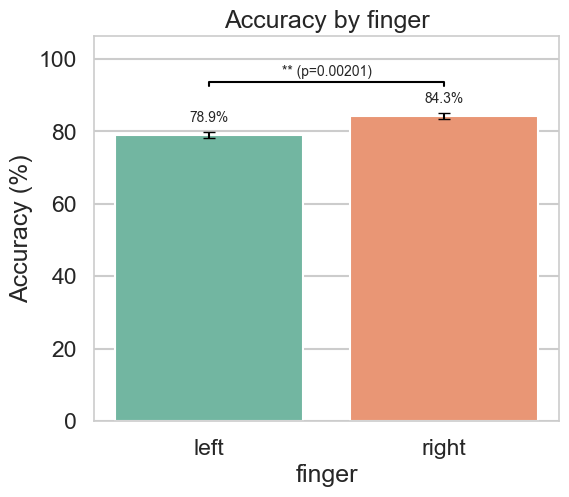

In [14]:
# Python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# 1) 准备数据：仅 subject / finger / correct，去缺失
df = result_df.dropna(subset=['subject','finger','correct']).copy()
N_TRIALS_PER_FINGER = 80  # 左手80，右手80

# 2) 每被试×finger 的正确率 acc（correct 是总数 -> 除以 80）
df_subj = (df.groupby(['subject','finger'], as_index=False)['correct']
             .sum()
             .rename(columns={'correct': 'correct_sum'}))
df_subj['acc'] = df_subj['correct_sum'] / N_TRIALS_PER_FINGER

# 3) 组内 SE（Cousineau–Morey；k=2）
grand = df_subj['acc'].mean()
df_subj['acc_norm'] = df_subj['acc'] - df_subj.groupby('subject')['acc'].transform('mean') + grand
se_ws = (df_subj.groupby('finger')['acc_norm']
         .agg(lambda x: x.std(ddof=1) / np.sqrt(len(x)))).rename('se_ws')
mean = df_subj.groupby('finger')['acc'].mean().rename('mean')
summary = pd.concat([mean, se_ws], axis=1).reset_index()
summary['mean_pct'] = summary['mean'] * 100
summary['se_pct'] = summary['se_ws'] * 100

# 4) 画图（两根柱子：finger=0,1）
sns.set(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(6, 5))
order = sorted(summary['finger'].unique())
plot_df = summary.sort_values('finger')

sns.barplot(
    data=plot_df, x='finger', y='mean_pct',
    hue='finger', palette='Set2', dodge=False, legend=False, ax=ax
)
# 误差条 + 数值标签
top = (plot_df['mean_pct'] + plot_df['se_pct']).max()
ax.set_ylim(0, top * 1.25)
ymin, ymax = ax.get_ylim(); yr = ymax - ymin
for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    ax.errorbar(x, y, yerr=row['se_pct'], fmt='none', ecolor='black',
                elinewidth=1.5, capsize=4)
    ax.text(x, y + row['se_pct'] + 0.02*yr, f'{row["mean_pct"]:.1f}%',
            ha='center', va='bottom', fontsize=10, clip_on=False)

# 5) 图上标注配对 t 检验（finger 0 vs 1）
pivot = df_subj.pivot(index='subject', columns='finger', values='acc')

# 兼容列名为 0/1 或 '0'/'1'/0.0/1.0
def find_col(cols, label):
    for key in (label, str(label), float(label)):
        if key in cols:
            return key
    return None

c0, c1 = find_col(pivot.columns, 0), find_col(pivot.columns, 1)
if c0 is not None and c1 is not None:
    tmp = pivot[[c0, c1]].dropna()
    if len(tmp) >= 2:
        res = pg.ttest(tmp[c0], tmp[c1], paired=True)
        p = float(res['p-val'].iloc[0])  # 用 iloc 避免 KeyError
        stars = 'ns' if p >= 0.05 else ('*' if p >= 0.01 else ('**' if p >= 0.001 else '***'))

        # 括号位置：用当前两根柱子的中心坐标和全局 top
        x0 = ax.patches[0].get_x() + ax.patches[0].get_width()/2
        x1 = ax.patches[1].get_x() + ax.patches[1].get_width()/2
        y_br = top + 0.08 * yr
        ax.plot([x0, x0, x1, x1], [y_br-0.01*yr, y_br, y_br, y_br-0.01*yr],
                color='black', linewidth=1.5)
        ax.text((x0+x1)/2, y_br + 0.01*yr, f'{stars} (p={p:.3g})',
                ha='center', va='bottom', fontsize=10)
    else:
        print('提示：用于配对 t 检验的被试不足（<2）。')
else:
    print('提示：未同时找到 finger=0 和 1 的列，跳过 t 检验标注。')

# 外框
for s in ['left','bottom','top','right']:
    ax.spines[s].set_visible(True); ax.spines[s].set_linewidth(1.2)

ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('finger')
ax.set_title('Accuracy by finger')

# x 轴仅改标签，不改数据
label_map = {'0':'left','1':'right','0.0':'left','1.0':'right'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

plt.show()

               Source       SS  ddof1  ddof2       MS       F  p-unc  \
0              finger  841.864      1     28  841.864  11.603  0.002   
1           frequency   45.312      1     28   45.312   1.112  0.301   
2  finger * frequency    6.519      1     28    6.519   0.139  0.712   

   p-GG-corr    ng2  eps  
0      0.002  0.072  1.0  
1      0.301  0.004  1.0  
2      0.712  0.001  1.0  


/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
/var/folders/wd/1vvvm8_1081fd4hv72tr3rrm0000gn/T/ipykernel_41148/3048031443.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


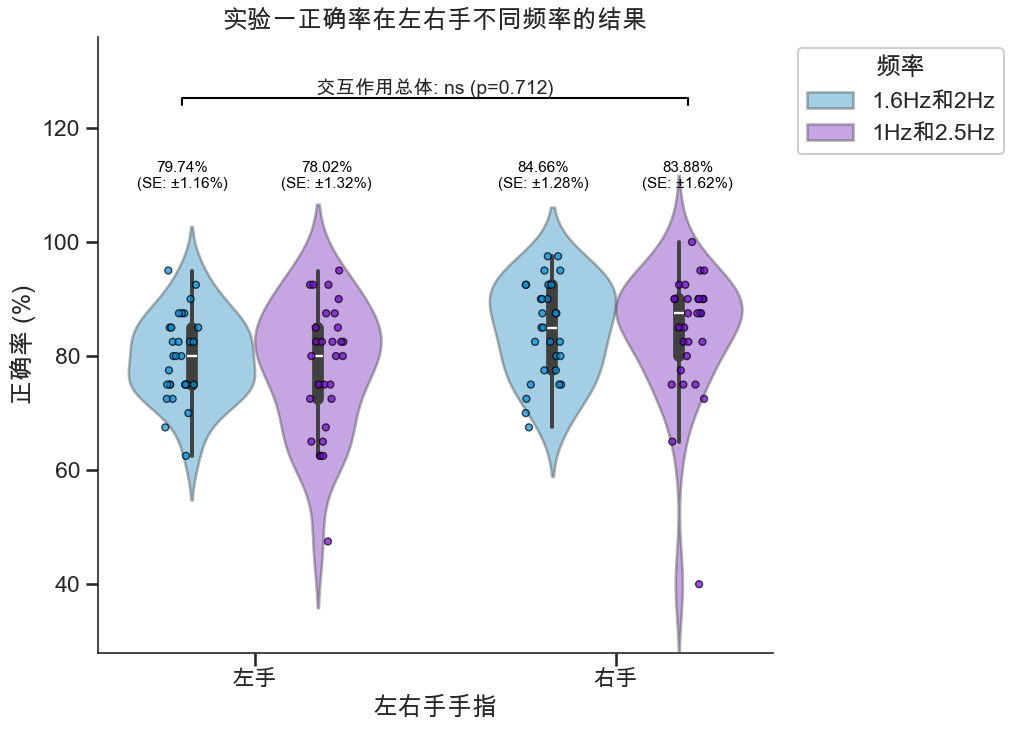

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# ---- 1) 解决 macOS 下中文显示问题 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # macOS 适用
plt.rcParams['axes.unicode_minus'] = False
# -----------------------------------

# 0) 基础数据
df = result_df.dropna(subset=['subject','finger','frequency','correct']).copy()

# 1) 每条件的试次数：左80/右80，按 frequency 平均分
n_freq = df['frequency'].nunique()
TRIALS_PER_FINGER = 80
trials_per_condition = TRIALS_PER_FINGER / n_freq  # 例如 40

# 2) 聚合到 被试×finger×frequency（计数 -> 正确率）
df_cond = (df.groupby(['subject','finger','frequency'], as_index=False)['correct']
             .sum()
             .rename(columns={'correct':'correct_sum'}))
df_cond['acc'] = df_cond['correct_sum'] / trials_per_condition  # 0–1 比例
df_cond['acc_pct'] = df_cond['acc'] * 100  # 转换为百分比用于画图和标值

# 3) 两因素 RM-ANOVA（用 acc_pct）
aov = pg.rm_anova(dv='acc_pct', within=['finger','frequency'], subject='subject',
                  data=df_cond, detailed=True, correction=True)
print(aov.round(3))

# 4) 组内 SE（Cousineau–Morey），k= finger×frequency 条件数
k = int(df_cond.groupby('subject').size().mode().iloc[0])  # 通常=2*n_freq
grand = df_cond['acc_pct'].mean()
df_cond['acc_norm'] = df_cond['acc_pct'] - df_cond.groupby('subject')['acc_pct'].transform('mean') + grand
morey = np.sqrt(k/(k-1)) if k > 1 else 1.0

summary = (df_cond.groupby(['finger','frequency'])
           .agg(mean=('acc_pct','mean'),
                se_ws=('acc_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
           .reset_index())
summary['se_ws'] *= morey

# 排序确保一一对应
finger_order = sorted(summary['finger'].unique(), key=lambda x: (str(type(x)), x))
hue_order = sorted(summary['frequency'].unique())

# ---- 5) 开始绘图：风琴图(小提琴图) + 散点(数据点) ----
sns.set(style='ticks', context='talk')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 8))

# 保持和反应时一致的颜色
custom_colors = ["#028DD8", "#7205D1"] 

# 画风琴图（透明度设为 alpha=0.4 以便看清散点）
sns.violinplot(
    data=df_cond, x='finger', y='acc_pct', hue='frequency',
    order=finger_order, hue_order=hue_order,
    inner="box", palette=custom_colors, ax=ax, width=0.7, density_norm="width", alpha=0.4
)

# 叠加原始数据点（stripplot），dodge=True 让点跟频率柱子对齐分开
sns.stripplot(
    data=df_cond, x='finger', y='acc_pct', hue='frequency',
    order=finger_order, hue_order=hue_order,
    dodge=True, edgecolor='black', linewidth=1, alpha=0.7, size=5, palette=custom_colors, ax=ax
)

# 动态计算Y轴上下限，给顶部的连线和均值文字留空间
y_max = df_cond['acc_pct'].max()
y_min = df_cond['acc_pct'].min()
yr = y_max - y_min  # Y轴的数据跨度
ax.set_ylim(y_min - 0.2 * yr, y_max + 0.6 * yr)  # 上端留白

# 在顶部标出均值(SE)
for i, finger in enumerate(finger_order):
    for j, freq in enumerate(hue_order):
        # 两个条件时，x偏移大约为 -0.2 和 0.2
        offset = -0.2 if j == 0 else 0.2
        x_pos = i + offset
        
        row = summary.loc[(summary['finger']==finger) & (summary['frequency']==freq)].iloc[0]
        m_val = row['mean']
        se_val = row['se_ws']
        
        # 显著降低遮挡，把平均值直接标注在上端
        ax.text(x_pos, y_max + 0.15 * yr, f'{m_val:.2f}%\n(SE: ±{se_val:.2f}%)',
                ha='center', va='bottom', fontsize=11, color='black')

# ---- 6) 添加 ANOVA 交互作用总体连线 ----
p_inter = aov[aov['Source'] == 'finger * frequency']['p-unc'].iloc[0]
stars_inter = 'ns' if p_inter >= 0.05 else ('*' if p_inter >= 0.01 else ('**' if p_inter >= 0.001 else '***'))

x_min, x_max = -0.2, len(finger_order) - 1 + 0.2
y_inter = y_max + 0.40 * yr  # 总体交互连线高度
ax.plot([x_min, x_min, x_max, x_max], [y_inter, y_inter + 0.02 * yr, y_inter + 0.02 * yr, y_inter], color='black', linewidth=1.5)
ax.text((x_min + x_max) / 2, y_inter + 0.02 * yr, f'交互作用总体: {stars_inter} (p={p_inter:.3g})', 
        ha='center', va='bottom', fontsize=14, fontweight='bold')

# ---- 7) 外观修饰 ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for side in ['left','bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)

ax.set_ylabel('正确率 (%)')
ax.set_xlabel('左右手手指')
ax.set_title('实验一正确率在左右手不同频率的结果')

# X 轴改为中文标签
label_map = {'0':'左手','1':'右手','0.0':'左手','1.0':'右手'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

# 清理并合并图例
handles, labels = ax.get_legend_handles_labels()
handles = handles[:len(hue_order)]
labels = labels[:len(hue_order)]

freq_map = {'1': '1.6Hz和2Hz', '2': '1Hz和2.5Hz'}  
new_labels = [freq_map.get(str(l).split('.')[0], str(l)) for l in labels]

ax.legend(handles=handles, labels=new_labels, title='频率', loc='upper left', bbox_to_anchor=(1.02, 1),
          frameon=True, framealpha=0.95)
plt.subplots_adjust(right=0.80)

plt.show()

               Source     SS  ddof1  ddof2     MS       F  p-unc  p-GG-corr  \
0              finger  0.084      1     28  0.084  11.603  0.002      0.002   
1           frequency  0.005      1     28  0.005   1.112  0.301      0.301   
2  finger * frequency  0.001      1     28  0.001   0.139  0.712      0.712   

     ng2  eps  
0  0.072  1.0  
1  0.004  1.0  
2  0.001  1.0  


/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
/var/folders/wd/1vvvm8_1081fd4hv72tr3rrm0000gn/T/ipykernel_28906/1477503743.py:174: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


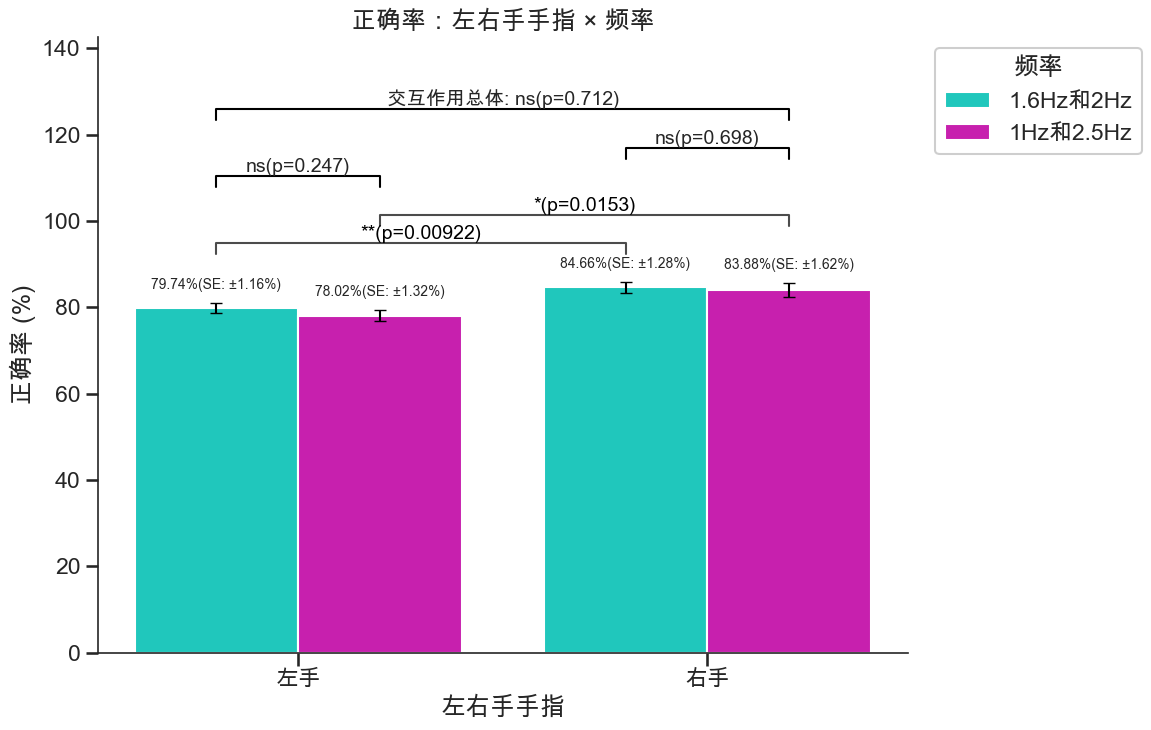

In [25]:
# Python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# ---- 1) 解决 macOS 下中文显示问题 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # macOS 适用
plt.rcParams['axes.unicode_minus'] = False
# -----------------------------------

# 0) 基础数据
df = result_df.dropna(subset=['subject','finger','frequency','correct']).copy()

# 1) 每条件的试次数：左80/右80，按 frequency 平均分
n_freq = df['frequency'].nunique()
TRIALS_PER_FINGER = 80
trials_per_condition = TRIALS_PER_FINGER / n_freq  # 例如 40
if TRIALS_PER_FINGER % n_freq != 0:
    print(f'注意：80 不能被 frequency 水平数 {n_freq} 整除，分母将用浮点 {trials_per_condition:g}')

# 2) 聚合到 被试×finger×frequency（计数 -> 正确率）
df_cond = (df.groupby(['subject','finger','frequency'], as_index=False)['correct']
             .sum()
             .rename(columns={'correct':'correct_sum'}))
df_cond['acc'] = df_cond['correct_sum'] / trials_per_condition  # 0–1 比例

# 3) 两因素 RM-ANOVA（用 acc）
aov = pg.rm_anova(dv='acc', within=['finger','frequency'], subject='subject',
                  data=df_cond, detailed=True, correction=True)
print(aov.round(3))

# 4) 组内 SE（Cousineau–Morey），k= finger×frequency 条件数
k = int(df_cond.groupby('subject').size().mode().iloc[0])  # 通常=2*n_freq
grand = df_cond['acc'].mean()
df_cond['acc_norm'] = df_cond['acc'] - df_cond.groupby('subject')['acc'].transform('mean') + grand
morey = np.sqrt(k/(k-1)) if k > 1 else 1.0

summary = (df_cond.groupby(['finger','frequency'])
           .agg(mean=('acc','mean'),
                se_ws=('acc_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
           .reset_index())
summary['se_ws'] *= morey
summary['mean_pct'] = summary['mean'] * 100
summary['se_pct'] = summary['se_ws'] * 100

# 5) 画分组柱状图 finger×frequency
# 改为无网格线背景
sns.set(style='ticks', context='talk')

# 注意：sns.set() 会重置字体设置，设定完主题后需要再次应用中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12,8))

# 使用与之前一致的自定义颜色
custom_colors = ["#04e3d4", "#e304c2"]

# 排序并确保误差条与柱子对齐
finger_order = sorted(summary['finger'].unique(), key=lambda x: (str(type(x)), x))
hue_order = sorted(summary['frequency'].unique())
summary['finger'] = pd.Categorical(summary['finger'], categories=finger_order, ordered=True)
summary['frequency'] = pd.Categorical(summary['frequency'], categories=hue_order, ordered=True)
plot_df = summary.sort_values(['finger','frequency']).reset_index(drop=True)

sns.barplot(
    data=plot_df, x='finger', y='mean_pct',
    hue='frequency', order=finger_order, hue_order=hue_order,
    errorbar=None, palette=custom_colors, ax=ax
)

# 上限留白放大为 1.5 倍，给两条线留足空间
top = (plot_df['mean_pct'] + plot_df['se_pct']).max()
ax.set_ylim(0, top * 1.5)

# 误差条 + 数值标签
ymin, ymax = ax.get_ylim(); yr = ymax - ymin

# 【核心修复】：Seaborn的 patch 顺序是按 hue 再按 x
patch_order_df = plot_df.sort_values(['frequency', 'finger']).reset_index(drop=True)

for patch, (_, row) in zip(ax.patches, patch_order_df.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    ax.errorbar(x, y, yerr=row['se_pct'], fmt='none', ecolor='black',
                elinewidth=1.5, capsize=4)
    # 平均值(SE: ±标准误) 保留两位小数，且添加百分号
    ax.text(x, y + row['se_pct'] + 0.02*yr, f'{row["mean_pct"]:.2f}%(SE: ±{row["se_pct"]:.2f}%)',
            ha='center', va='bottom', fontsize=10, clip_on=False)
    
# ---- 2) 添加简单效应(配对t检验) ----
# 第一组：同一频次下，手指0 vs 1
y_line_freq = top + 0.05 * yr
if len(finger_order) >= 2:
    val_f1, val_f2 = finger_order[0], finger_order[1]
    for j, freq in enumerate(hue_order):
        d1 = df_cond[(df_cond['finger'] == val_f1) & (df_cond['frequency'] == freq)].set_index('subject')['acc']
        d2 = df_cond[(df_cond['finger'] == val_f2) & (df_cond['frequency'] == freq)].set_index('subject')['acc']
        common = d1.index.intersection(d2.index)
        if len(common) >= 2:
            res = pg.ttest(d1.loc[common], d2.loc[common], paired=True)
            p_val = float(res['p-val'].iloc[0])
            stars = 'ns' if p_val >= 0.05 else ('*' if p_val >= 0.01 else ('**' if p_val >= 0.001 else '***'))
            
            # 获取对应的两个柱子的中心 x 坐标
            x0 = ax.patches[j * len(finger_order)].get_x() + ax.patches[j * len(finger_order)].get_width() / 2
            x1 = ax.patches[j * len(finger_order) + 1].get_x() + ax.patches[j * len(finger_order) + 1].get_width() / 2
            
            y_line = y_line_freq + j * 0.05 * yr
            # c = 'blue' if j == 0 else 'purple'
            ax.plot([x0, x0, x1, x1], [y_line, y_line + 0.02 * yr, y_line + 0.02 * yr, y_line], color='black', linewidth=1.5, alpha=0.7)
            ax.text((x0 + x1) / 2, y_line + 0.02 * yr, f'{stars}(p={p_val:.3g})', ha='center', va='bottom', fontsize=14, color='black')

# 第二组：同一手指下，频次1 vs 2
y_line_finger = y_line_freq + 0.12 * yr
for i, fing in enumerate(finger_order):
    if len(hue_order) >= 2:
        val1, val2 = hue_order[0], hue_order[1]
        
        # 取两个 frequency 分组
        d1 = df_cond[(df_cond['finger'] == fing) & (df_cond['frequency'] == val1)].set_index('subject')['acc']
        d2 = df_cond[(df_cond['finger'] == fing) & (df_cond['frequency'] == val2)].set_index('subject')['acc']
        
        common_subjects = d1.index.intersection(d2.index)
        if len(common_subjects) >= 2:
            res = pg.ttest(d1.loc[common_subjects], d2.loc[common_subjects], paired=True)
            p_val = float(res['p-val'].iloc[0])
            stars = 'ns' if p_val >= 0.05 else ('*' if p_val >= 0.01 else ('**' if p_val >= 0.001 else '***'))
            
            # 获取对应的两个柱子的中心 x 坐标
            x0 = ax.patches[i].get_x() + ax.patches[i].get_width() / 2
            x1 = ax.patches[i + len(finger_order)].get_x() + ax.patches[i + len(finger_order)].get_width() / 2
            
            # 绘制连线
            y_line = y_line_finger + i * 0.05 * yr
            ax.plot([x0, x0, x1, x1], [y_line, y_line + 0.02 * yr, y_line + 0.02 * yr, y_line], color='black', linewidth=1.5)
            ax.text((x0 + x1) / 2, y_line + 0.02 * yr, f'{stars}(p={p_val:.3g})', ha='center', va='bottom', fontsize=14)

# ---- 3) 添加 ANOVA 交互作用总体连线 ----
# 提取交互作用的 p 值 (从步骤3生成的 aov 提取)
p_inter = aov[aov['Source'] == 'finger * frequency']['p-unc'].iloc[0]
stars_inter = 'ns' if p_inter >= 0.05 else ('*' if p_inter >= 0.01 else ('**' if p_inter >= 0.001 else '***'))

# 获取所有柱子的 x 坐标
all_x = [p.get_x() + p.get_width() / 2 for p in ax.patches]
x_min, x_max = min(all_x), max(all_x)

# 绘制最高层的交互作用连线
y_inter = y_line_finger + 0.12 * yr 
ax.plot([x_min, x_min, x_max, x_max], [y_inter, y_inter + 0.02 * yr, y_inter + 0.02 * yr, y_inter], color='black', linewidth=1.5)
ax.text((x_min + x_max) / 2, y_inter + 0.02 * yr, f'交互作用总体: {stars_inter}(p={p_inter:.3g})', ha='center', va='bottom', fontsize=14, fontweight='bold')
# -------------------------------------

ax.set_ylim(0, y_inter + 0.15 * yr)

# ====== 新增加这下面两行 ======
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ==============================

# 外框与标签
for s in ['left','bottom']:
    ax.spines[s].set_visible(True)
    ax.spines[s].set_linewidth(1.2)

ax.set_ylabel('正确率 (%)')
ax.set_xlabel('左右手手指')
ax.set_title('正确率：左右手手指 × 频率')

# 自适应 X 轴中文标签
label_map = {'0':'左手','1':'右手','0.0':'左手','1.0':'右手'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

# legend 放轴外右上角并预留空间
handles, labels = ax.get_legend_handles_labels()

# ---- 【在这里把 '1' 和 '2' 替换成你想要的真实频率名称】 ----
freq_map = {'1': '1.6Hz和2Hz', '2': '1Hz和2.5Hz'}  
# ----------------------------------------------------

# 解析并自动替换图表自带的 '1' 或 '1.0' / '2' 或 '2.0'
new_labels = [freq_map.get(str(l).split('.')[0], str(l)) for l in labels]

ax.legend(handles=handles, labels=new_labels, title='频率', loc='upper left', bbox_to_anchor=(1.02, 1),
          frameon=True, framealpha=0.95)
plt.subplots_adjust(right=0.80)


plt.show()